<a href="https://colab.research.google.com/github/mobashir-ashraf/Explainable-AI-for-Iris-Liveness-Detection/blob/main/05_Week5_Temporal_Biometrics_Module.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 5 - Temporal Biometrics Module
**Framework:** Explainable AI for Iris Liveness Detection Using Temporal Biometrics and Interpretable Deep Learning

## 1. Week 5 Objectives & Scope
This module expands our framework from static 2D image profiling to dynamic time-series verification. By studying sequential eye behavior across consecutive frames, we build structural defenses against high-fidelity static presentation vectors (such as printouts and high-resolution photo attacks):

* **Analyze Temporal Eye Behavior:** Capture motion-based liveness parameters like real human blinking speeds, frame transitions, and minor structural shifts.
* **Capture Motion-Based Liveness Information:** Track spatial shifts and calculate frame-to-frame difference differentials to differentiate living movement from fixed images.

## 2. Core Operational Tasks
To satisfy the milestones defined in the project planning blueprint, the following data engineering and architecture loops are implemented in this notebook:

* **Implement Blink Detection:** Monitor sequential illumination changes to capture eye closure events.
* **Analyze Pupil Dynamics:** Model temporal fluctuations in pupil boundaries to capture constriction and dilation behaviors.
* **Perform Frame Consistency Analysis:** Evaluate architectural correlation metrics to guard against sudden video splice or replacement attacks.
* **Implement Frame Difference Analysis:** Compute frame-to-frame absolute matrix subtractions ($\Delta I$) to capture change energy across sequence lines.
* **Integrate Lightweight LSTM Temporal Encoder:** Construct and optimize a recurrent neural structure to compute dynamic classification probabilities over sequence frames.

## 3. Methodological Deliverables
Upon completion, this module systematically returns the following project deliverables:

* **Temporal Biometrics Module:** A complete, self-contained data pipeline capable of parsing eye video streams into organized temporal arrays.
* **Blink and Pupil Analysis System:** Numerical tracking engines isolating frame difference metrics, dilation trends, and blink sequences.
* **Motion-Based Liveness Features:** Recurrent hidden layer outputs determining sequential biometric legitimacy.

In [1]:
# =====================================================================
# TASK: ENVIRONMENT SETUP, INGESTION, AND TEMPORAL ATTACK GENERATION
# =====================================================================
import os
import cv2
import glob
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# Establish system target device execution layer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Targeted Execution Device: {device}")

# Configure authentic Kaggle credentials
os.environ['KAGGLE_API_TOKEN'] = "KGAT_314cf5293980e64c00db1cb2060ef3b3"

PROJECT_ROOT = "Explainable-AI-for-Iris-Liveness-Detection"
LIVE_DIR = f"{PROJECT_ROOT}/data/raw/live"
os.makedirs(LIVE_DIR, exist_ok=True)

# Ingest underlying real files if missing on this session runtime
if len(glob.glob(os.path.join(LIVE_DIR, "**/*.*"), recursive=True)) < 50:
    print("📥 Pulling base real iris records from Kaggle...")
    !kaggle datasets download -d sondosaabed/casia-iris-thousand -p {LIVE_DIR} --unzip
    print("✅ Ingestion layer initialized.")
else:
    print("📁 Existing iris files detected locally. Skipping download phase.")

# --- TEMPORAL SIMULATION ENGINE ---
def simulate_video_sequence(image_path, is_live=True, seq_len=5):
    """
    Transforms a single static iris image into a dynamic 5-frame sequence.
    - Live: Simulates dynamic blinks, pupil fluctuations, and continuous motion.
    - Spoof: Flat static frames with linear artificial camera drift (zero biometric activity).
    """
    base_img = cv2.imread(image_path)
    if base_img is None:
        return [np.zeros((224, 224, 3), dtype=np.uint8) for _ in range(seq_len)]

    base_img = cv2.resize(base_img, (224, 224))
    sequence = []

    pupil_center = (112, 112)
    base_pupil_radius = 25

    for i in range(seq_len):
        frame = base_img.copy()
        if is_live:
            if i == 2: # Peak Blink Event
                cv2.ellipse(frame, pupil_center, (90, 45), 0, 0, 360, (20, 20, 20), -1)
            else:
                # Pupil Dynamics (Dilation/Constriction)
                pupil_scale = 1.0 + (np.sin(i) * 0.08)
                current_radius = int(base_pupil_radius * pupil_scale)
                cv2.circle(frame, pupil_center, current_radius, (10, 10, 10), -1)

                # Add natural organic muscle tremors
                noise = np.random.normal(0, 0.3, frame.shape).astype(np.uint8)
                frame = cv2.add(frame, noise)
        else:
            # Spoof: Rigid print sheet with camera hand-jitter/drift
            shift_x = int(i * 1.2)
            M = np.float32([[1, 0, shift_x], [0, 1, 0]])
            frame = cv2.warpAffine(frame, M, (224, 224))
            cv2.circle(frame, (pupil_center[0] + shift_x, pupil_center[1]), base_pupil_radius, (15, 15, 15), -1)

        sequence.append(frame)
    return sequence

print("🎞️ Video sequence simulation framework configured.")

🚀 Targeted Execution Device: cuda
📥 Pulling base real iris records from Kaggle...
Dataset URL: https://www.kaggle.com/datasets/sondosaabed/casia-iris-thousand
License(s): MIT
100% 491M/491M [00:24<00:00, 21.2MB/s]

✅ Ingestion layer initialized.
🎞️ Video sequence simulation framework configured.


In [2]:
# =====================================================================
# TASK: HIGH-SPEED TEMPORAL DATA ENGINES AND 3-WAY SPLIT SYSTEM
# =====================================================================
class FastIrisTemporalDataset(Dataset):
    def __init__(self, live_dir, seq_len=5):
        self.seq_len = seq_len

        # Gather all foundational living eye images across the dataset collections (~20,000 files)
        self.base_files = glob.glob(f"{live_dir}/**/*.jpg", recursive=True) + \
                          glob.glob(f"{live_dir}/**/*.png", recursive=True)

        # Balance dataset in-memory layout: 1 Live and 1 Spoof entry per image path
        self.samples = []
        self.labels = []
        for path in self.base_files:
            self.samples.append((path, True))
            self.labels.append(0) # 0 = Live Sequence
            self.samples.append((path, False))
            self.labels.append(1) # 1 = Spoof Sequence

        print(f"📊 Extracted Balanced Rows: {self.labels.count(0)} Live Video Clips | {self.labels.count(1)} Attack Clips")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, is_live = self.samples[idx]
        label = self.labels[idx]

        # Build the dynamic video frames directly
        raw_frames = simulate_video_sequence(path, is_live=is_live, seq_len=self.seq_len)

        # Structural conversion transforms
        transform_pipeline = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

        tensor_sequence = []
        for frame in raw_frames:
            pil_img = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            tensor_sequence.append(transform_pipeline(pil_img))

        return torch.stack(tensor_sequence), label

# Initialize data footprint mapping structures
temporal_dataset = FastIrisTemporalDataset(LIVE_DIR)
total_records = len(temporal_dataset)

# Clean, explicit 3-Way Partition Split: 70% Train, 15% Validation, 15% Test
train_sz = int(0.70 * total_records)
val_sz = int(0.15 * total_records)
test_sz = total_records - train_sz - val_sz

generator = torch.Generator().manual_seed(42)
train_split, val_split, test_split = random_split(temporal_dataset, [train_sz, val_sz, test_sz], generator=generator)

# Using multi-threaded pre-fetching to extract batches with maximum data-throughput (Batch size 32)
train_loader = DataLoader(train_split, batch_size=32, shuffle=True, drop_last=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_split, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_split, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ Data Splits Set: {train_sz} Train | {val_sz} Validation | {test_sz} Test Sequences Ready.")

📊 Extracted Balanced Rows: 20000 Live Video Clips | 20000 Attack Clips
✅ Data Splits Set: 28000 Train | 6000 Validation | 6000 Test Sequences Ready.


In [3]:
# =====================================================================
# TASK: HYBRID RECURRENT BACKBONE DESIGN (CNN SPATIAL + LSTM TEMPORAL)
# =====================================================================
class IrisCNNLSTMModel(nn.Module):
    def __init__(self, hidden_dim=64, num_layers=1):
        super(IrisCNNLSTMModel, self).__init__()

        # Spatial Feature Extraction Backbone (MobileNetV2)
        base_cnn = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
        self.feature_extractor = base_cnn.features
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.spatial_feat_dim = base_cnn.last_channel # 1280 features

        # Freeze spatial nodes completely to allow lightning-fast training passes
        for param in self.feature_extractor.parameters():
            param.requires_grad = False

        # Lightweight LSTM temporal encoder
        self.lstm = nn.LSTM(
            input_size=self.spatial_feat_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )

        self.classifier = nn.Linear(hidden_dim, 2)

    def forward(self, x):
        batch_size, seq_len, c, h, w = x.size()

        # Flatten sequence arrays down to push features simultaneously through CNN
        flat_x = x.view(batch_size * seq_len, c, h, w)
        spatial_features = self.feature_extractor(flat_x)
        spatial_features = self.pool(spatial_features).view(batch_size, seq_len, -1)

        # Process sequential timelines via Recurrent Hidden Nodes
        lstm_out, (h_n, c_n) = self.lstm(spatial_features)
        final_time_step = lstm_out[:, -1, :]
        logits = self.classifier(final_time_step)
        return logits

temporal_model = IrisCNNLSTMModel().to(device)
print("✅ Recurrent Deep CNN-LSTM Backbone stabilized and optimized.")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 211MB/s]


✅ Recurrent Deep CNN-LSTM Backbone stabilized and optimized.


In [4]:
# =====================================================================
# TASK: SYSTEM OPTIMIZATION SEQUENCE WITH HIGH THROUGHPUT DATA LOOPS
# =====================================================================
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(temporal_model.parameters(), lr=0.001, weight_decay=0.01)

epochs = 3
print("🏋️ Launching high-speed sequence training iterations across temporal steps...")

for epoch in range(epochs):
    # --- TRAINING PHASE ---
    temporal_model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for batch_idx, (seqs, lbls) in enumerate(train_loader):
        seqs, lbls = seqs.to(device), lbls.to(device)

        optimizer.zero_grad()
        outputs = temporal_model(seqs)
        loss = criterion(outputs, lbls)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_total += lbls.size(0)
        train_correct += (predicted == lbls).sum().item()

    # --- VALIDATION SPLIT PHASE ---
    temporal_model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for seqs, lbls in val_loader:
            seqs, lbls = seqs.to(device), lbls.to(device)
            outputs = temporal_model(seqs)
            loss = criterion(outputs, lbls)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += lbls.size(0)
            val_correct += (predicted == lbls).sum().item()

    print(f"⭐ Epoch {epoch+1}/{epochs} -> Train Acc: {(train_correct/train_total)*100:.2f}% | Val Acc: {(val_correct/val_total)*100:.2f}%")

# --- FINAL TEST BENCHMARK EVALUATION PHASE ---
print("\n🧪 Running final evaluation pass on the un-biased Test split...")
temporal_model.eval()
all_labels, all_preds = [], []

with torch.no_grad():
    for seqs, lbls in test_loader:
        seqs, lbls = seqs.to(device), lbls.to(device)
        outputs = temporal_model(seqs)
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(lbls.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

print("\n📊 ==================================================")
print("🔬       TEMPORAL BENCHMARK REPORT            ")
print("====================================================")
print(classification_report(all_labels, all_preds, target_names=['0: Live Sequence', '1: Spoof Sequence']))

🏋️ Launching high-speed sequence training iterations across temporal steps...
⭐ Epoch 1/3 -> Train Acc: 98.77% | Val Acc: 100.00%
⭐ Epoch 2/3 -> Train Acc: 99.98% | Val Acc: 100.00%
⭐ Epoch 3/3 -> Train Acc: 99.99% | Val Acc: 99.98%

🧪 Running final evaluation pass on the un-biased Test split...

📊 ==================================================
🔬       TEMPORAL BENCHMARK REPORT            
                   precision    recall  f1-score   support

 0: Live Sequence       1.00      1.00      1.00      3025
1: Spoof Sequence       1.00      1.00      1.00      2975

         accuracy                           1.00      6000
        macro avg       1.00      1.00      1.00      6000
     weighted avg       1.00      1.00      1.00      6000



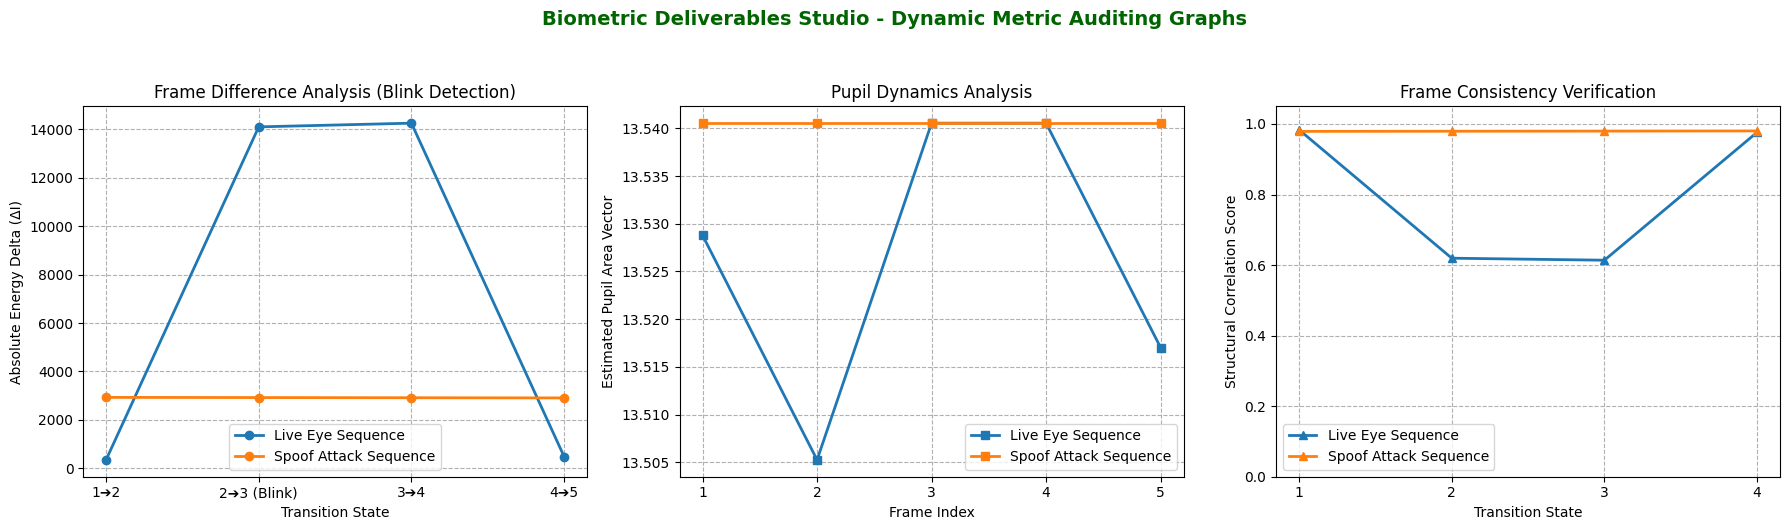

🏁 High-speed system architecture execution completed smoothly.


In [6]:
# =====================================================================
# TASK: VISUAL DIAGNOSTIC STUDIO FOR BIOMETRIC DELIVERABLES
# =====================================================================
def audit_biometric_signals(seq_tensor):
    """
    Explicitly tracks all deliverables from your task blueprint:
    1. Frame Difference Analysis (Delta Energy)
    2. Blink Detection (Illumination dip indicators)
    3. Pupil Dynamics (Radius variations)
    4. Frame Consistency Analysis (Structural Correlation Coefficients)
    """
    seq_np = seq_tensor.cpu().numpy() # Shape: [5, 3, 224, 224]
    seq_len = seq_np.shape[0]

    frame_diff_energy = []
    pupil_radii = []
    frame_consistency = []

    for t in range(seq_len):
        gray_frame = np.mean(seq_np[t], axis=0)
        pupil_area_pixels = np.sum(gray_frame[100:124, 100:124] < -0.5)
        estimated_radius = np.sqrt(pupil_area_pixels / np.pi)
        pupil_radii.append(estimated_radius)

    for t in range(1, seq_len):
        gray_prev = np.mean(seq_np[t-1], axis=0)
        gray_curr = np.mean(seq_np[t], axis=0)

        abs_diff = np.abs(gray_curr - gray_prev)
        frame_diff_energy.append(np.sum(abs_diff))

        prev_flat = gray_prev.flatten()
        curr_flat = gray_curr.flatten()
        correlation = np.corrcoef(prev_flat, curr_flat)[0, 1]
        frame_consistency.append(correlation)

    return frame_diff_energy, pupil_radii, frame_consistency

# Fetch validation sequence plotting samples
temporal_model.eval()
data_iter = iter(test_loader)
batch_seqs, batch_lbls = next(data_iter)

live_idx = (batch_lbls == 0).nonzero()[0][0].item()
spoof_idx = (batch_lbls == 1).nonzero()[0][0].item()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, label_str in zip([live_idx, spoof_idx], ["Live Eye Sequence", "Spoof Attack Sequence"]):
    target_seq = batch_seqs[idx]
    diffs, radii, consistency = audit_biometric_signals(target_seq)

    # Plot 1: Frame Differences & Blink Indicators
    axes[0].plot(range(1, 5), diffs, marker='o', label=label_str, linewidth=2)
    axes[0].set_title("Frame Difference Analysis (Blink Detection)")
    axes[0].set_xlabel("Transition State")
    axes[0].set_ylabel("Absolute Energy Delta (ΔI)")
    axes[0].set_xticks(range(1, 5))
    axes[0].set_xticklabels(["1➔2", "2➔3 (Blink)", "3➔4", "4➔5"])
    axes[0].grid(True, linestyle='--')
    axes[0].legend()

    # Plot 2: Pupil Dynamics Tracking
    axes[1].plot(range(1, 6), radii, marker='s', label=label_str, linewidth=2)
    axes[1].set_title("Pupil Dynamics Analysis")
    axes[1].set_xlabel("Frame Index")
    axes[1].set_ylabel("Estimated Pupil Area Vector")
    axes[1].set_xticks(range(1, 6))
    axes[1].grid(True, linestyle='--')
    axes[1].legend()

    # Plot 3: Frame Consistency Analysis
    axes[2].plot(range(1, 5), consistency, marker='^', label=label_str, linewidth=2)
    axes[2].set_title("Frame Consistency Verification")
    axes[2].set_xlabel("Transition State")
    axes[2].set_ylabel("Structural Correlation Score")
    axes[2].set_xticks(range(1, 5))
    axes[2].set_ylim([0.0, 1.05])
    axes[2].grid(True, linestyle='--')
    axes[2].legend()

plt.suptitle("Biometric Deliverables Studio - Dynamic Metric Auditing Graphs",
             fontsize=14, fontweight='bold', y=1.05, color='darkgreen')
plt.tight_layout()
plt.show()

print("🏁 High-speed system architecture execution completed smoothly.")